Aleksander Hański 160315 and Karol Okoń ??????

First we perform web scraping using this code ('spiders/minecraft_wki.py'):

In [ ]:
class WikipediaSpider(scrapy.Spider):
    name = "wikipedia"
    allowed_domains = ["en.wikipedia.org"]
    start_urls = ["https://en.wikipedia.org/wiki/Albert_Camus"]
    
    custom_settings = {
        'USER_AGENT': 'Olek-and-Karol',
        'DEPTH_LIMIT': 2,
        'CLOSESPIDER_PAGECOUNT': 100,
        'DOWNLOAD_DELAY': 1,
    }

    def parse(self, response):
        content = response.css("#mw-content-text .mw-parser-output")

        # Exclude tables, references, navboxes
        for element in content.css('table, .reflist, .navbox, .mw-editsection'):
            element.drop()

        text = content.css("p::text, p a::text").getall()
        text = " ".join(t.strip() for t in text if t.strip())

        yield {
            "url": response.url,
            "text": text
        }

        for href in response.css(".mw-parser-output a::attr(href)").getall():
            if href.startswith("/wiki/") and ":" not in href:
                yield response.follow(href, self.parse)

Then we process our downloaded articles, we first clean text, then we process it - we use WordNetLemmatizer, tokenize text and get rid of stop words. We save both cleaned text and processed tokens to csv file. We do this in file 'processing_articles.py'

In [2]:
import json
import re

from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import pandas as pd


def clean_text(text):
    # Remove URLs
    text = re.sub(r'https?://\S+', '', text)

    # Remove edition-only tags like [Bedrock Edition only]
    #text = re.sub(r'\[\s*\w+(\s+\w+)*\s+only\s*\]', '', text, flags=re.IGNORECASE)
    # maybe too agressive, commented out for now

    # Remove reference brackets like [1], [2], etc.
    text = re.sub(r'\[\s*\d+\s*\]', '', text)
    
    # Remove standalone brackets like [ ]
    text = re.sub(r'\[\s*\]', '', text)
    
    # Remove excessive whitespace
    text = re.sub(r'\s+', ' ', text)
    
    # Remove spaces before punctuation
    text = re.sub(r'\s+([.,!?])', r'\1', text)

    # Remove section headers pattern (words followed by [ ])
    text = re.sub(r'(\w+)\s*\[\s*\]', r'\1', text)

    # Remove lines that are just navigation/menu items
    text = re.sub(r'\b\d+(\.\d+)*\s+[A-Z][a-z]+\b', '', text)  # Like "9.1 Mash-up Packs"
    
    return text.strip()


def process_text(text):

    lemmatizer = WordNetLemmatizer()
    
    stop_words = set(stopwords.words('english'))
    
    tokens = word_tokenize(text.lower())
    
    processed_tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token.isalpha() and token not in stop_words
    ]
    
    return processed_tokens


def process_json_to_csv(input_filename, output_filename):
    with open(input_filename, 'r') as f:
        data = json.load(f)
    
    rows = []
    for entry in data:
        cleaned_text = clean_text(entry['text'])
        processed_tokens = process_text(cleaned_text)
        rows.append({
            'url': entry['url'],
            'cleaned_text': cleaned_text,
            'processed_tokens': ' '.join(processed_tokens)
        })
    
    df = pd.DataFrame(rows)
    df.to_csv(output_filename, index=False, encoding='utf-8')


process_json_to_csv('output.json', 'wiki_processed.csv')

File 'main.py'.

First we ask user for articles, user inputs links in a loop until she types 'q' to quit.
Then again we clean text and process it to tokens using same functions as before.
We save cleande text and tokens to another csv file.

In [3]:
import requests
from bs4 import BeautifulSoup

def download_article_text(filename='project1/input_articles.csv'):
    headers = {
        'User-Agent': 'Olek-and-Karol'
    }

    rows = []

    while True:
        url = input("Enter article URL (or 'q' to quit): ")
        if url.lower() == 'q':
            break
        
        response = requests.get(url, headers=headers)
        response.raise_for_status()
        
        parsed = BeautifulSoup(response.text, 'html.parser')
        
        text = ''
        for p in parsed.select('p'):
            text += p.get_text() + ' '

        cleaned_text = clean_text(text)
        processed_tokens = process_text(cleaned_text)
        
        rows.append({
            'url': url,
            'cleaned_text': cleaned_text,
            'processed_tokens': ' '.join(processed_tokens)
        })

    df = pd.DataFrame(rows)
    df.to_csv(filename, index=False, encoding='utf-8')

download_article_text(filename='input_articles.csv')

Our function to find similar articles. First we use TF-IDF vectorizer to filter out 50 most similar articles, then on those 50 articles we perform hybrid scoring - 0.5 weight to TF-IDF, the other 0.5 to semantic embeddings. 

TFIDF (term frequency-inverse document frequency) - frequency of a term in document is multiplied by inverse document frequency, measure of how much information the word provides, if word is less common and appears in smaller amount of articles then the fact that two articles share that word matters more on their similarity. We use TfidfVectorizer from sklearn library for that.

Semantic - uses semantic embeddings, what captures meaning and relationships between words better, but is much more computationally expensive, also it can miss specific keywords that really matter in short texts. We use SentenceTransformer('all-MiniLM-L6-v2'). 

First we load our user input csv and our base of articles csv files contents to dataframe.

For both base and input articles we will replace possible NaN values with empty strings so that TF-IDF vectorizer or model dont crash, both from cleaned text and tokens.
Then for input articles we get rid of possible empty articles.

We compute tfidf matrix for all base tokens, then from this we exclude idxs of articles that possibly were also given as input. 
We sort articles by similarity, and for 50 candidates with highest similarity score we sompute both semantic similarity and tfidf - semantic model is generally better but it is slower than tfidf. 

Then we normalize similarities:
- TF-IDF similarities tend to be low, often 0.05 - 0.3
- Semantic similarities tend to be higher, often 0.4 - 0.8
So without normalization semantic similarities would influence final prediction much more. 

Then we assign 0.5 weight to similarities for TFIDF, and 0.5 weight to similarities from semantic model in final prediction. Semantic model although captures meaning better can miss on specific words in shorter texts, so we still want to include TFIDF in our final prediction.



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import numpy as np


def find_similar_articles(input_csv='input_articles.csv',
                                    base_csv='wiki_processed.csv',
                                    top_k=5,
                                    candidate_count=50,
                                    hybrid_weight=0.5):
    """
    Two-stage similarity search: TF-IDF to narrow candidates, then hybrid (tfidf and semantic) to rank best articles.
    
    top_k: Number of recommendations to return
    candidate_count: Number of candidates to keep after TF-IDF stage
    hybrid_weight: Weight for TF-IDF in hybrid scoring (0-1)
    """
    
    df = pd.read_csv(base_csv)
    new_df = pd.read_csv(input_csv)
    
    base_tokens = df['processed_tokens'].fillna('')
    base_texts = df['cleaned_text'].fillna('')
    
    input_tokens = new_df['processed_tokens'].dropna().astype(str)
    input_tokens = input_tokens[input_tokens.str.strip() != '']    
    input_texts = new_df['cleaned_text'].dropna().astype(str)
    input_texts = input_texts[input_texts.str.strip() != '']
    
    if input_tokens.empty and input_texts.empty:
        print("No valid input articles found")
        return []

    # Exclude input articles
    input_urls = set(new_df['url'].dropna())
    mask = ~df['url'].isin(input_urls)

    print(input_tokens)
    # stage 1: tfidf to get candidates
    tfidf_sims_all = compute_tfidf_similarity(input_tokens, base_tokens)
    print(tfidf_sims_all)
    # exclude input articles from considered articles in base
    masked_tfidf = np.where(mask, tfidf_sims_all, -1)
    candidate_idx = masked_tfidf.argsort()[-candidate_count:]

    # stage 2: hybrid scoring on best candidates only
    candidate_tokens = base_tokens.iloc[candidate_idx]
    candidate_texts = base_texts.iloc[candidate_idx]
    
    tfidf_sims = compute_tfidf_similarity(input_tokens, candidate_tokens)
    semantic_sims = compute_semantic_similarity(input_texts, candidate_texts)
    
    tfidf_norm = normalize_scores(tfidf_sims)
    semantic_norm = normalize_scores(semantic_sims)
    combined_sims = hybrid_weight * tfidf_norm + (1 - hybrid_weight) * semantic_norm

    top_local_idx = combined_sims.argsort()[-top_k:][::-1]
    top_idx = candidate_idx[top_local_idx]

    results = [
        {
            'url': df.iloc[idx].get('url', ''),
            'similarity': float(combined_sims[local_idx]),
            'preview': str(df.iloc[idx].get('cleaned_text', ''))[:200]
        }
        for local_idx, idx in zip(top_local_idx, top_idx)
    ]


    print(f"\nRECOMMENDATIONS:\n")
    for i, r in enumerate(results, 1):
        print(f"\n{i}. {r['url']}")
        print(f"Similarity score: {r['similarity']:.4f}")
        print(f"Preview: {r['preview']}...")
        print("-" * 40)


def normalize_scores(scores):
    min_score = scores.min()
    max_score = scores.max()
    
    if max_score == min_score:
        return np.zeros_like(scores)
    
    return (scores - min_score) / (max_score - min_score)

**tfidf_matrix = vectorizer.fit_transform(base_tokens)** - this does two things:

- fit: learns vocabulary from all base articles (e.g., discovers there are 5000 unique words)
- transform: converts each base article into a vector of 5000 numbers

Then with 1000 base articles tfidf matrix will have shape (1000, 5000)

**input_vectors = vectorizer.transform(input_tokens)**

This line only transforms input tokens into a vector based on vocabulary it learned from base of articles.

Then we compute similarity of every input vector to every vector in the base of articles using cosine similarity.

**return all_sims.mean(axis=0)** - for each base articles we return mean of its similarities to each input article, this way for each base article we got one score

In [11]:
def compute_tfidf_similarity(input_tokens, base_tokens):
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(base_tokens)
    input_vectors = vectorizer.transform(input_tokens)
    
    all_sims = cosine_similarity(input_vectors, tfidf_matrix)
    return all_sims.mean(axis=0)

Similarly as in compute_tfidf_similarity function, this time we use ready sentence transformer model.

In [ ]:
def compute_semantic_similarity(input_texts, base_texts):
    model = SentenceTransformer('all-MiniLM-L6-v2')
    
    base_embeddings = model.encode(base_texts.tolist(), show_progress_bar=False)
    input_embeddings = model.encode(input_texts.tolist(), show_progress_bar=False)
    
    all_sims = cosine_similarity(input_embeddings, base_embeddings)
    return all_sims.mean(axis=0)

Corpus Statistics:
Total articles: 114
Average text length: 19817 characters
Average tokens per article: 1687


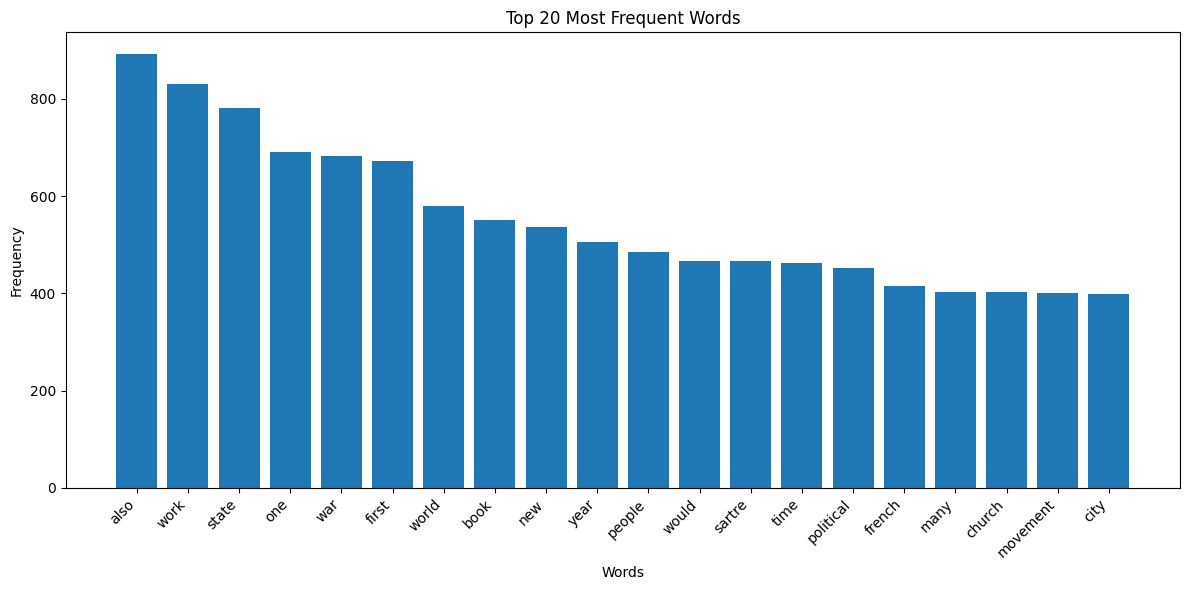

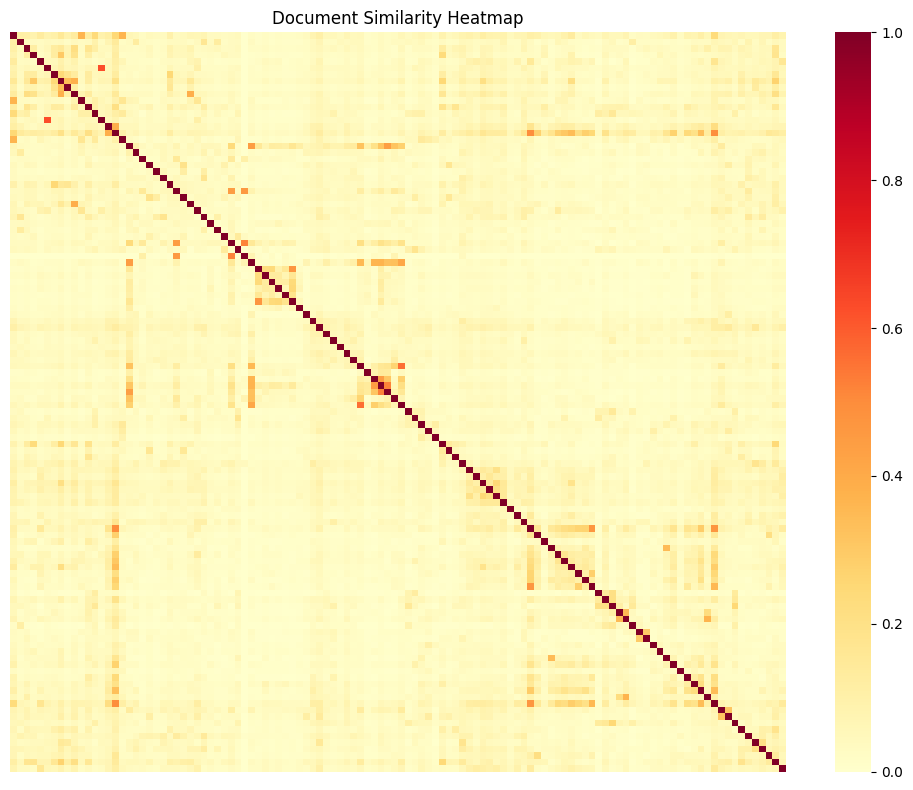

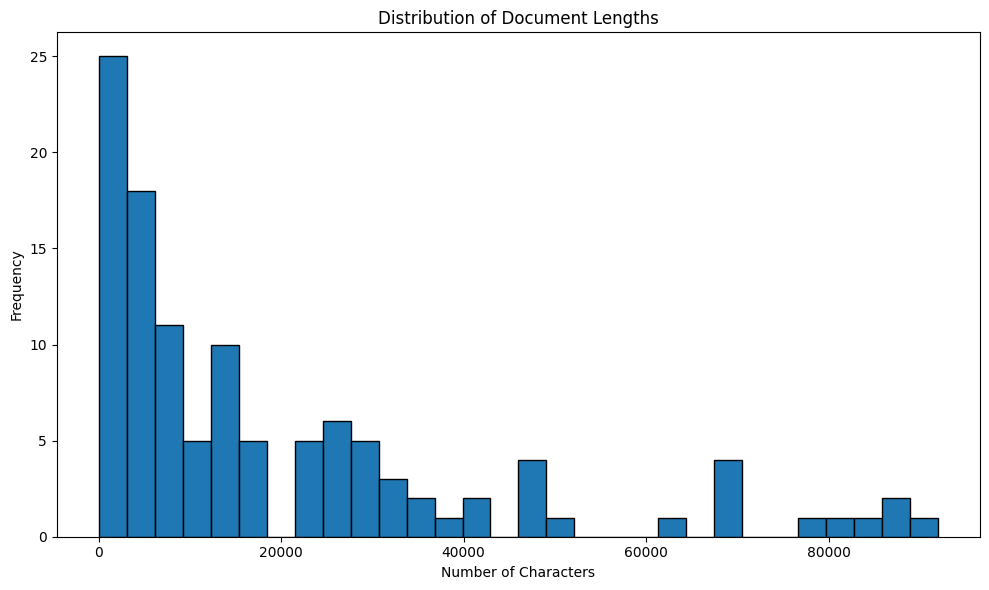

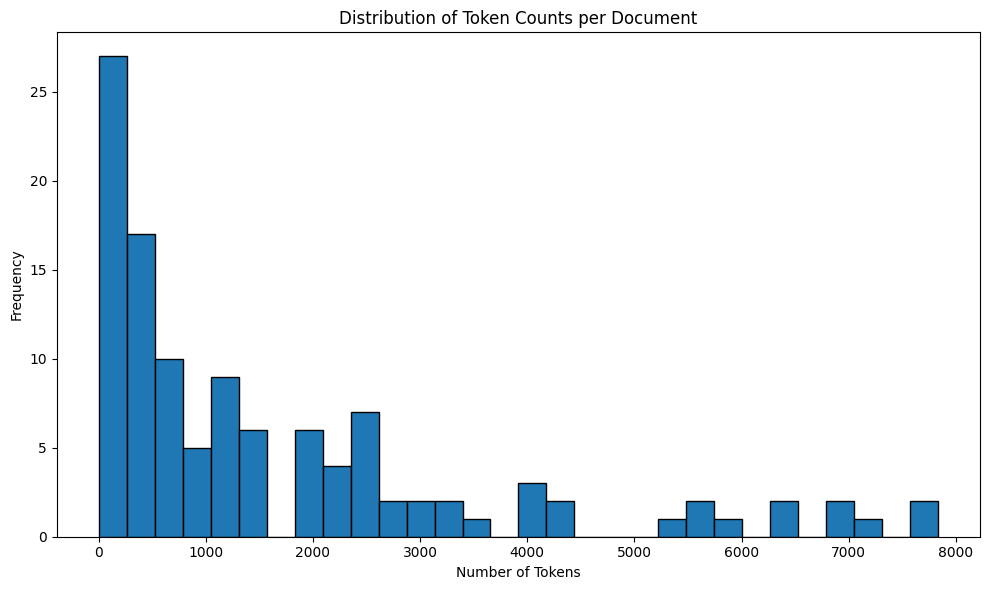

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage

vectorizer = TfidfVectorizer()
df = pd.read_csv('wiki_processed.csv')
tfidf_matrix = vectorizer.fit_transform(df['processed_tokens'])
        

total_articles = len(df)
avg_text_length = df['cleaned_text'].str.len().mean()
avg_tokens = df['processed_tokens'].str.split().str.len().mean()
        
print(f"Corpus Statistics:")
print(f"Total articles: {total_articles}")
print(f"Average text length: {avg_text_length:.0f} characters")
print(f"Average tokens per article: {avg_tokens:.0f}")
        

all_tokens = ' '.join(df['processed_tokens']).split()
word_freq = Counter(all_tokens)

top_n = 20
top_words = dict(word_freq.most_common(top_n))
        
plt.figure(figsize=(12, 6))
plt.bar(top_words.keys(), top_words.values())
plt.xticks(rotation=45, ha='right')
plt.title(f'Top {top_n} Most Frequent Words')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
        

sim_matrix = cosine_similarity(tfidf_matrix)
        
plt.figure(figsize=(10, 8))
sns.heatmap(sim_matrix, 
            xticklabels=False, 
            yticklabels=False,
            cmap='YlOrRd')
plt.title('Document Similarity Heatmap')
plt.tight_layout()
plt.show()
        

doc_lengths = df['cleaned_text'].str.len()
        
plt.figure(figsize=(10, 6))
plt.hist(doc_lengths, bins=30, edgecolor='black')
plt.title('Distribution of Document Lengths')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
        

token_counts = df['processed_tokens'].str.split().str.len()
        
plt.figure(figsize=(10, 6))
plt.hist(token_counts, bins=30, edgecolor='black')
plt.title('Distribution of Token Counts per Document')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()